# Assignment 3 - Recommender Systems
MovieLens ml-latest-small dataset

In [125]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)

In [126]:
base_path = Path("/Users/bvijay/MLBD_Assignment3/ml-latest-small")

movies  = pd.read_csv(base_path / "movies.csv")
ratings = pd.read_csv(base_path / "ratings.csv")

print(movies.shape, ratings.shape)
movies.head(3)

(9742, 3) (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


In [127]:
print("users :", ratings["userId"].nunique())
print("movies:", ratings["movieId"].nunique())
print("rating range:", ratings["rating"].min(), "-", ratings["rating"].max())

users : 610
movies: 9724
rating range: 0.5 - 5.0


## Part 1 - Content Based Filtering
### Task 1: TF-IDF Recommendation

In [128]:
# genres are pipe separated, replace with space so tfidf treats each as a token
movies["genres_clean"] = movies["genres"].str.replace("|", " ", regex=False)
movies["genres_clean"] = movies["genres_clean"].replace("(no genres listed)", "")
movies[["title", "genres_clean"]].head()

,title,genres_clean
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,Jumanji (1995),Adventure Children Fantasy
2,Grumpier Old Men (1995),Comedy Romance
3,Waiting to Exhale (1995),Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy


In [129]:
tfidf = TfidfVectorizer(min_df=1, stop_words=None)
tfidf_matrix = tfidf.fit_transform(movies["genres_clean"])
print(tfidf_matrix.shape)
print(tfidf.get_feature_names_out())

(9742, 21)
['action' 'adventure' 'animation' 'children' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'fi' 'film' 'horror' 'imax' 'musical'
 'mystery' 'noir' 'romance' 'sci' 'thriller' 'war' 'western']


In [130]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print(cosine_sim.shape)

(9742, 9742)


In [131]:
movies = movies.reset_index(drop=True)
title_to_idx = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

def tfidf_recommend(title, top_n=5):
    if title not in title_to_idx:
        raise ValueError(f"{title} not found")
    idx = title_to_idx[title]
    sims = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
    sims = [(i, s) for i, s in sims if i != idx][:top_n]
    result = movies.iloc[[i for i, _ in sims]][["title", "genres"]].copy()
    result["score"] = [round(s, 4) for _, s in sims]
    return result.reset_index(drop=True)

In [132]:
for q in ["Toy Story (1995)", "Fargo (1996)", "Matrix, The (1999)"]:
    print(f"\n{q}")
    print(tfidf_recommend(q).to_string(index=False))


Toy Story (1995)
                                         title                                      genres  score
                                   Antz (1998) Adventure|Animation|Children|Comedy|Fantasy    1.0
                            Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy    1.0
Adventures of Rocky and Bullwinkle, The (2000) Adventure|Animation|Children|Comedy|Fantasy    1.0
              Emperor's New Groove, The (2000) Adventure|Animation|Children|Comedy|Fantasy    1.0
                         Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy    1.0

Fargo (1996)
                                                title                      genres  score
                                  Pulp Fiction (1994) Comedy|Crime|Drama|Thriller    1.0
                                       Freeway (1996) Comedy|Crime|Drama|Thriller    1.0
Man Bites Dog (C'est arrivé près de chez vous) (1992) Comedy|Crime|Drama|Thriller    1.0
                        

### Task 2: User Profile Based Recommendation

In [133]:
movieid_to_row = pd.Series(movies.index, index=movies["movieId"])
tfidf_dense = tfidf_matrix.toarray()

def build_user_profile(user_id):
    # weighted average of tfidf vectors of movies user rated
    # higher rated movies contribute more: P_u = sum(r*f) / sum(r)
    ur = ratings[ratings["userId"] == user_id]
    ur = ur[ur["movieId"].isin(movieid_to_row.index)]
    if ur.empty:
        return None
    wsum = np.zeros(tfidf_dense.shape[1])
    total = 0.0
    for _, row in ur.iterrows():
        wsum  += row["rating"] * tfidf_dense[movieid_to_row[row["movieId"]]]
        total += row["rating"]
    return wsum / total if total > 0 else None

p = build_user_profile(1)
print("profile shape:", p.shape)

profile shape: (21,)


In [134]:
def user_profile_recommend(user_id, top_n=10, exclude_seen=True):
    profile = build_user_profile(user_id)
    if profile is None:
        return pd.DataFrame()
    sims = cosine_similarity(profile.reshape(1, -1), tfidf_dense).flatten()
    if exclude_seen:
        seen = set(ratings[ratings["userId"] == user_id]["movieId"])
        seen_rows = set(movieid_to_row[m] for m in seen if m in movieid_to_row.index)
        sims[list(seen_rows)] = -1
    top_idx = np.argsort(sims)[::-1][:top_n]
    result = movies.iloc[top_idx][["title", "genres"]].copy()
    result["similarity"] = sims[top_idx].round(4)
    return result.reset_index(drop=True)

print(user_profile_recommend(1).to_string(index=False))

                                        title                                          genres  similarity
        Dragonheart 2: A New Beginning (2000)  Action|Adventure|Comedy|Drama|Fantasy|Thriller      0.7910
                    Hunting Party, The (2007)          Action|Adventure|Comedy|Drama|Thriller      0.7736
               The Great Train Robbery (1978)             Action|Adventure|Comedy|Crime|Drama      0.7731
                             Flashback (1990)             Action|Adventure|Comedy|Crime|Drama      0.7731
                      After the Sunset (2004)          Action|Adventure|Comedy|Crime|Thriller      0.7605
Diamond Arm, The (Brilliantovaya ruka) (1968)          Action|Adventure|Comedy|Crime|Thriller      0.7605
       Charlie's Angels: Full Throttle (2003)          Action|Adventure|Comedy|Crime|Thriller      0.7605
                               Machete (2010)          Action|Adventure|Comedy|Crime|Thriller      0.7605
                          Maximum Ride (2016) 

In [135]:
def precision_recall_at_k(user_id, k=10, threshold=4.0):
    liked = set(ratings[(ratings["userId"] == user_id) & (ratings["rating"] >= threshold)]["movieId"])
    if not liked:
        return 0.0, 0.0
    recs    = user_profile_recommend(user_id, top_n=k, exclude_seen=False)
    rec_ids = set(movies.loc[movies["title"].isin(recs["title"]), "movieId"])
    hits = len(liked & rec_ids)
    return round(hits / k, 4), round(hits / len(liked), 4)

results = [precision_recall_at_k(u) for u in ratings["userId"].unique()[:30]]
print(f"Avg P@10={np.mean([r[0] for r in results]):.4f}  R@10={np.mean([r[1] for r in results]):.4f}")

Avg P@10=0.0333  R@10=0.0067


## Part 2 - Collaborative Filtering
### Task 3: User Based CF

In [136]:
user_item = ratings.pivot_table(index="userId", columns="movieId", values="rating")
print(user_item.shape)
print(f"sparsity: {100 * user_item.isnull().sum().sum() / user_item.size:.1f}%")

(610, 9724)
sparsity: 98.3%


In [137]:
# pearson handles rating bias better than cosine (e.g. one user always rates 5, another 3)
user_similarity = user_item.T.corr(method="pearson")
print(user_similarity.shape)

(610, 610)


In [138]:
def ubcf_predict_rating(user_id, movie_id, k=20):
    if movie_id not in user_item.columns:
        return np.nan
    sims = user_similarity[user_id].drop(labels=[user_id], errors="ignore")
    sims = sims[user_item[movie_id].notna()].dropna().sort_values(ascending=False)
    if sims.empty:
        return np.nan
    top_sims = sims.iloc[:k]
    top_rats = user_item.loc[top_sims.index, movie_id]
    denom = top_sims.abs().sum()
    if denom == 0:
        return np.nan
    return float(np.clip((top_sims * top_rats).sum() / denom, 0.5, 5.0))


def ubcf_recommend(user_id, k=20, top_n=10):
    rated = set(user_item.loc[user_id].dropna().index)
    preds = {}
    for mid in [m for m in user_item.columns if m not in rated]:
        p = ubcf_predict_rating(user_id, mid, k=k)
        if not np.isnan(p):
            preds[mid] = p
    if not preds:
        return pd.DataFrame()
    top = sorted(preds, key=preds.get, reverse=True)[:top_n]
    result = movies[movies["movieId"].isin(top)][["movieId", "title", "genres"]].copy()
    result["predicted"] = result["movieId"].map(preds).round(2)
    return result.sort_values("predicted", ascending=False).reset_index(drop=True)


print(ubcf_recommend(1).to_string(index=False))

 movieId                                          title                         genres  predicted
     148               Awfully Big Adventure, An (1995)                          Drama        5.0
     496                    What Happened Was... (1994)  Comedy|Drama|Romance|Thriller        5.0
     633                         Denise Calls Up (1995)                         Comedy        5.0
     876 Supercop 2 (Project S) (Chao ji ji hua) (1993)   Action|Comedy|Crime|Thriller        5.0
    1151                            Lesson Faust (1994) Animation|Comedy|Drama|Fantasy        5.0
    1631                         Assignment, The (1997)                Action|Thriller        5.0
    1696                                    Bent (1997)                      Drama|War        5.0
    2075                                Mephisto (1981)                      Drama|War        5.0
    2196                               Knock Off (1998)                         Action        5.0
    2824            

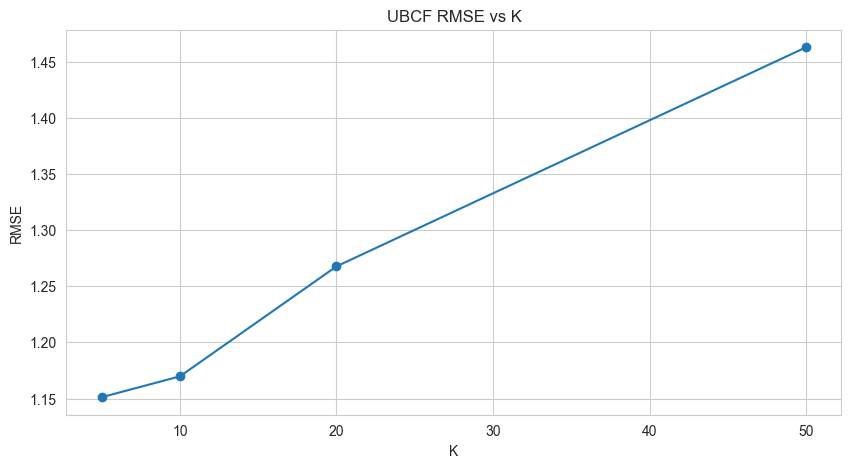

K=5  RMSE=1.1512
K=10  RMSE=1.1697
K=20  RMSE=1.2677
K=50  RMSE=1.4629


In [139]:
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=SEED)

user_item_train = train_ratings.pivot_table(index="userId", columns="movieId", values="rating")
user_sim_train  = user_item_train.T.corr(method="pearson")


def ubcf_rmse(test_df, k=20, sample=500):
    sample_df = test_df.sample(min(sample, len(test_df)), random_state=SEED)
    errors = []
    for _, row in sample_df.iterrows():
        uid, mid, true_r = int(row["userId"]), int(row["movieId"]), row["rating"]
        if uid not in user_sim_train.index or mid not in user_item_train.columns:
            continue
        sims = user_sim_train[uid].drop(labels=[uid], errors="ignore")
        sims = sims[user_item_train[mid].notna()].dropna().sort_values(ascending=False)
        if sims.empty:
            continue
        top_sims = sims.iloc[:k]
        top_rats = user_item_train.loc[top_sims.index, mid]
        denom = top_sims.abs().sum()
        if denom == 0:
            continue
        pred = float(np.clip((top_sims * top_rats).sum() / denom, 0.5, 5.0))
        errors.append((pred - true_r) ** 2)
    return float(np.sqrt(np.mean(errors))) if errors else float("nan")


k_values  = [5, 10, 20, 50]
rmse_vals = [ubcf_rmse(test_ratings, k=k) for k in k_values]

plt.plot(k_values, rmse_vals, marker="o")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("UBCF RMSE vs K")
plt.show()

for k, r in zip(k_values, rmse_vals):
    print(f"K={k}  RMSE={r:.4f}")

In [140]:
def ubcf_pr_at_k(user_id, k=10, threshold=4.0):
    liked = set(test_ratings[(test_ratings["userId"] == user_id) & (test_ratings["rating"] >= threshold)]["movieId"])
    if not liked:
        return 0.0, 0.0
    recs = ubcf_recommend(user_id, k=20, top_n=k)
    hits = len(liked & set(recs["movieId"]))
    return round(hits / k, 4), round(hits / len(liked), 4)


scores = [ubcf_pr_at_k(u) for u in ratings["userId"].unique()[:20]]
print(f"UBCF  P@10={np.mean([s[0] for s in scores]):.4f}  R@10={np.mean([s[1] for s in scores]):.4f}")

UBCF  P@10=0.0000  R@10=0.0000


### Task 4: Item Based CF

In [141]:
item_sim_df = pd.DataFrame(
    cosine_similarity(user_item.fillna(0).T),
    index=user_item.columns,
    columns=user_item.columns
)
print(item_sim_df.shape)

(9724, 9724)


In [142]:
def ibcf_predict_rating(user_id, movie_id, k=20):
    if user_id not in user_item.index or movie_id not in item_sim_df.index:
        return np.nan
    user_rated = user_item.loc[user_id].dropna()
    rated_movies = user_rated.index.intersection(item_sim_df.columns)
    if len(rated_movies) == 0:
        return np.nan
    top_sims = item_sim_df.loc[movie_id, rated_movies].sort_values(ascending=False).iloc[:k]
    top_rats = user_rated[top_sims.index]
    denom = top_sims.abs().sum()
    if denom == 0:
        return np.nan
    return float(np.clip((top_sims * top_rats).sum() / denom, 0.5, 5.0))


def ibcf_recommend(user_id, k=20, top_n=10):
    if user_id not in user_item.index:
        return pd.DataFrame()
    rated = set(user_item.loc[user_id].dropna().index)
    preds = {}
    for mid in [m for m in user_item.columns if m not in rated]:
        p = ibcf_predict_rating(user_id, mid, k=k)
        if not np.isnan(p):
            preds[mid] = p
    if not preds:
        return pd.DataFrame()
    top = sorted(preds, key=preds.get, reverse=True)[:top_n]
    result = movies[movies["movieId"].isin(top)][["movieId", "title", "genres"]].copy()
    result["predicted"] = result["movieId"].map(preds).round(2)
    return result.sort_values("predicted", ascending=False).reset_index(drop=True)


print(ibcf_recommend(1).to_string(index=False))

 movieId                                             title                           genres  predicted
    1140 Entertaining Angels: The Dorothy Day Story (1996)                            Drama        5.0
    1519                             Broken English (1996)                            Drama        5.0
    2896                              Alvarez Kelly (1966)                          Western        5.0
    3106                      Come See the Paradise (1990)                    Drama|Romance        5.0
    3899                                     Circus (2000)             Crime|Drama|Thriller        5.0
    6158                         Jungle Book 2, The (2003)               Animation|Children        5.0
   26366                       Harlan County U.S.A. (1976)                      Documentary        5.0
   44633             Devil and Daniel Johnston, The (2005)                      Documentary        5.0
   58309                                  War Dance (2007)               

In [143]:
u = 5
print("overlap UBCF vs IBCF:", len(
    set(ubcf_recommend(u)["title"]) & set(ibcf_recommend(u)["title"])
), "/ 10")

overlap UBCF vs IBCF: 0 / 10


In [144]:
# item-based CF is more scalable in practice because the item-item similarity
# matrix is m x m (movies x movies) which stays small even as users grow.
# UBCF needs an n x n matrix which blows up quickly with user growth.
# Also item similarities can be precomputed offline and cached since
# new movies are added rarely compared to new user ratings.
print("see comment above")

see comment above


## Part 3 - Matrix Factorization
### Task 5: SVD

In [145]:
# fill NaN with per-user mean before SVD
user_item_filled = user_item.apply(lambda row: row.fillna(row.mean()), axis=1)
R = user_item_filled.values.astype(float)
print("R shape:", R.shape)

R shape: (610, 9724)


In [146]:
K_FACTORS = 50

U, sigma, Vt = svds(R, k=K_FACTORS)

# svds returns ascending order, flip to descending
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]

R_hat = np.clip(U @ np.diag(sigma) @ Vt, 0.5, 5.0)
R_hat_df = pd.DataFrame(R_hat, index=user_item.index, columns=user_item.columns)
print(R_hat.shape)

(610, 9724)


In [147]:
def svd_recommend(user_id, top_n=10):
    if user_id not in R_hat_df.index:
        return pd.DataFrame()
    rated = set(user_item.loc[user_id].dropna().index)
    preds = R_hat_df.loc[user_id].drop(index=list(rated), errors="ignore")
    top   = preds.nlargest(top_n).index.tolist()
    result = movies[movies["movieId"].isin(top)][["movieId", "title", "genres"]].copy()
    result["predicted"] = result["movieId"].map(preds).round(2)
    return result.sort_values("predicted", ascending=False).reset_index(drop=True)


print(svd_recommend(1).to_string(index=False))

 movieId                                                                       title                                              genres  predicted
     541                                                         Blade Runner (1982)                              Action|Sci-Fi|Thriller       4.72
     344                                           Ace Ventura: Pet Detective (1994)                                              Comedy       4.66
    1246                                                   Dead Poets Society (1989)                                               Drama       4.63
    2804                                                   Christmas Story, A (1983)                                     Children|Comedy       4.60
    4011                                                               Snatch (2000)                               Comedy|Crime|Thriller       4.60
    7153                       Lord of the Rings: The Return of the King, The (2003)                      Action

In [148]:
def evaluate_rmse(pred_df, test_df, sample=1000):
    df = test_df.sample(min(sample, len(test_df)), random_state=SEED)
    sq = []
    for _, row in df.iterrows():
        uid, mid = int(row["userId"]), int(row["movieId"])
        if uid in pred_df.index and mid in pred_df.columns:
            sq.append((pred_df.loc[uid, mid] - row["rating"]) ** 2)
    return float(np.sqrt(np.mean(sq))) if sq else float("nan")


rmse_svd = evaluate_rmse(R_hat_df, test_ratings)
print(f"SVD RMSE: {rmse_svd:.4f}")
print(f"Best UBCF RMSE: {min(rmse_vals):.4f}")

SVD RMSE: 0.6367
Best UBCF RMSE: 1.1512


### Task 6: Surprise SVD

In [149]:
import numpy
import surprise

print(numpy.__version__)

1.26.4


In [150]:
from surprise import Dataset, Reader, SVD as SurpriseSVD
from surprise.model_selection import train_test_split as surprise_split, GridSearchCV
from surprise import accuracy as surprise_accuracy

reader        = Reader(rating_scale=(0.5, 5.0))
surprise_data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)
trainset, testset = surprise_split(surprise_data, test_size=0.2, random_state=SEED)
print("train:", trainset.n_ratings, " test:", len(testset))

train: 80668  test: 20168


In [151]:
param_grid = {
    "n_factors": [50, 100],
    "n_epochs":  [20, 30],
    "lr_all":    [0.005, 0.01],
    "reg_all":   [0.02, 0.1],
}

gs = GridSearchCV(SurpriseSVD, param_grid, measures=["rmse"], cv=3, n_jobs=-1, refit=True)
gs.fit(surprise_data)
print("best RMSE:", round(gs.best_score["rmse"], 4))
print("best params:", gs.best_params["rmse"])

best RMSE: 0.8631
best params: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}


In [152]:
best_svd = gs.best_estimator["rmse"]
best_svd.fit(trainset)

predictions_svd = best_svd.test(testset)
rmse_surprise   = surprise_accuracy.rmse(predictions_svd, verbose=False)

print(f"Surprise SVD RMSE: {rmse_surprise:.4f}")
print(f"Manual SVD RMSE  : {rmse_svd:.4f}")
# surprise uses SGD with regularisation so it generalises better than
# filling NaN with user means and doing a full matrix reconstruction

Surprise SVD RMSE: 0.8615
Manual SVD RMSE  : 0.6367


In [153]:
from collections import defaultdict


def surprise_pr_at_k(predictions, k=10, threshold=3.5):
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((est, true_r))
    prec, rec = [], []
    for uid, upreds in user_preds.items():
        upreds.sort(key=lambda x: x[0], reverse=True)
        top_k  = upreds[:k]
        n_rel  = sum(1 for _, tr in upreds if tr >= threshold)
        n_hit  = sum(1 for est, tr in top_k if est >= threshold and tr >= threshold)
        prec.append(n_hit / k)
        rec.append(n_hit / n_rel if n_rel > 0 else 0)
    return round(np.mean(prec), 4), round(np.mean(rec), 4)


p, r = surprise_pr_at_k(predictions_svd)
print(f"Surprise SVD  P@10={p}  R@10={r}")

Surprise SVD  P@10=0.5639  R@10=0.5174


## Part 4 - Hybrid Model
### Task 7: Meta-Learning (CBF + CF)

In [154]:
from sklearn.ensemble import GradientBoostingRegressor

movie_avg_rating = ratings.groupby("movieId")["rating"].mean()
user_avg_rating  = ratings.groupby("userId")["rating"].mean()

print("building user profiles...")
user_profiles = {}
for uid in tqdm(train_ratings["userId"].unique()[:200]):
    p = build_user_profile(uid)
    if p is not None:
        user_profiles[uid] = p
print(len(user_profiles), "profiles ready")

building user profiles...


100%|██████████| 200/200 [00:00<00:00, 231.21it/s]

200 profiles ready


In [155]:
def build_meta_features(df):
    gm = ratings["rating"].mean()
    rows = []
    for _, row in df.iterrows():
        uid, mid = int(row["userId"]), int(row["movieId"])
        if uid in user_profiles and mid in movieid_to_row.index:
            cbf = float(cosine_similarity(
                user_profiles[uid].reshape(1, -1),
                tfidf_dense[movieid_to_row[mid]].reshape(1, -1)
            )[0][0])
        else:
            cbf = 0.0
        cf    = float(R_hat_df.loc[uid, mid]) if uid in R_hat_df.index and mid in R_hat_df.columns else gm
        pop   = float(movie_avg_rating.get(mid, gm))
        ubias = float(user_avg_rating.get(uid, gm))
        rows.append({"cbf": cbf, "cf": cf, "movie_avg": pop, "user_avg": ubias, "true": row["rating"]})
    return pd.DataFrame(rows)


print("building features...")
tr_df = train_ratings[train_ratings["userId"].isin(user_profiles)].sample(3000, random_state=SEED)
te_df = test_ratings[test_ratings["userId"].isin(user_profiles)].sample(500,  random_state=SEED)

meta_train = build_meta_features(tr_df)
meta_test  = build_meta_features(te_df)

X_train = meta_train[["cbf", "cf", "movie_avg", "user_avg"]]
y_train = meta_train["true"]
X_test  = meta_test[["cbf", "cf", "movie_avg", "user_avg"]]
y_test  = meta_test["true"]

building features...


In [156]:
meta_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=SEED)
meta_model.fit(X_train, y_train)

preds_hybrid   = np.clip(meta_model.predict(X_test), 0.5, 5.0)
preds_cf_only  = np.clip(X_test["cf"].values, 0.5, 5.0)
preds_cbf_only = MinMaxScaler(feature_range=(0.5, 5.0)).fit_transform(X_test[["cbf"]]).flatten()

rmse_hybrid   = np.sqrt(mean_squared_error(y_test, preds_hybrid))
rmse_cf_only  = np.sqrt(mean_squared_error(y_test, preds_cf_only))
rmse_cbf_only = np.sqrt(mean_squared_error(y_test, preds_cbf_only))

print(f"Hybrid : {rmse_hybrid:.4f}")
print(f"CF only: {rmse_cf_only:.4f}")
print(f"CBF only:{rmse_cbf_only:.4f}")

Hybrid : 0.4379
CF only: 0.5136
CBF only:1.4030


In [157]:
user_rating_counts = ratings.groupby("userId").size()
aug = te_df.copy().reset_index(drop=True)
aug["n_ratings"] = aug["userId"].map(user_rating_counts)
aug["pred"]      = preds_hybrid
aug["sq_err"]    = (aug["pred"] - aug["rating"]) ** 2
aug["user_type"] = pd.cut(aug["n_ratings"],
                           bins=[0, 20, 100, np.inf],
                           labels=["cold (<=20)", "warm (21-100)", "hot (>100)"])

print(aug.groupby("user_type", observed=True)["sq_err"].apply(lambda x: round(np.sqrt(x.mean()), 4)))
# cold start users have higher error since CF signal is weak for them

user_type
warm (21-100)    0.6555
hot (>100)       0.4258
Name: sq_err, dtype: float64


## Part 5 - Learning Based Recommender
### Task 8: Neural Network CBF

In [158]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(SEED)
print("TF:", tf.__version__)

TF: 2.16.2


In [159]:
genre_dummies = movies["genres"].str.get_dummies(sep="|")
genre_dummies = genre_dummies.drop(columns=["(no genres listed)"], errors="ignore")

movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)
movies["year"] = movies["year"].fillna(movies["year"].median())

mov_avg = ratings.groupby("movieId")["rating"].mean().rename("avg_rating")
movies  = movies.join(mov_avg, on="movieId")
movies["avg_rating"] = movies["avg_rating"].fillna(ratings["rating"].mean())

movies["year_norm"]   = MinMaxScaler().fit_transform(movies[["year"]])
movies["avg_r_norm"]  = MinMaxScaler().fit_transform(movies[["avg_rating"]])

movie_feat_df = pd.concat(
    [genre_dummies, movies[["year_norm", "avg_r_norm"]].reset_index(drop=True)], axis=1
)
movie_feat_df.index = movies["movieId"]
print(movie_feat_df.shape)

(9742, 21)


In [160]:
genre_cols = genre_dummies.columns.tolist()

rg = ratings.merge(
    pd.concat([movies[["movieId"]], genre_dummies.set_index(movies["movieId"])], axis=1).reset_index(drop=True),
    on="movieId", how="left"
)
wsum = rg.groupby("userId")[genre_cols].apply(lambda g: (g.T * rg.loc[g.index, "rating"]).T.sum())
rsum = rg.groupby("userId")["rating"].sum()
user_feat_df = wsum.div(rsum, axis=0).fillna(0)
print(user_feat_df.shape)

(610, 19)


In [161]:
print(nn_data.columns.tolist())

['userId', 'movieId', 'rating', 'timestamp', 'u_Action', 'u_Adventure', 'u_Animation', 'u_Children', 'u_Comedy', 'u_Crime', 'u_Documentary', 'u_Drama', 'u_Fantasy', 'u_Film-Noir', 'u_Horror', 'u_IMAX', 'u_Musical', 'u_Mystery', 'u_Romance', 'u_Sci-Fi', 'u_Thriller', 'u_War', 'u_Western', 'm_Action', 'm_Adventure', 'm_Animation', 'm_Children', 'm_Comedy', 'm_Crime', 'm_Documentary', 'm_Drama', 'm_Fantasy', 'm_Film-Noir', 'm_Horror', 'm_IMAX', 'm_Musical', 'm_Mystery', 'm_Romance', 'm_Sci-Fi', 'm_Thriller', 'm_War', 'm_Western', 'year_norm', 'avg_r_norm']


In [162]:
# movie feature columns (before merge)
mf_cols = list(genre_dummies.columns) + ["year_norm", "avg_r_norm"]

# merge data
nn_data = ratings.merge(
    user_feat_df.reset_index().rename(columns={"index": "userId"}),
    on="userId",
    how="inner"
).merge(
    movie_feat_df.reset_index(),
    on="movieId",
    how="inner"
)

nn_data = nn_data.rename(columns={
    c: "u_" + c.replace("_x", "")
    for c in nn_data.columns if c.endswith("_x")
})

nn_data = nn_data.rename(columns={
    c: "m_" + c.replace("_y", "")
    for c in nn_data.columns if c.endswith("_y")
})

u_cols = [c for c in nn_data.columns if c.startswith("u_")]
m_cols = [c for c in nn_data.columns if c.startswith("m_")]

# prepare inputs
X_u = nn_data[u_cols].values.astype("float32")
X_m = nn_data[m_cols].values.astype("float32")

# normalize target
y = ((nn_data["rating"].values - 0.5) / 4.5).astype("float32")

# train-test split
sp = int(0.8 * len(y))
X_u_tr, X_u_te = X_u[:sp], X_u[sp:]
X_m_tr, X_m_te = X_m[:sp], X_m[sp:]
y_tr, y_te     = y[:sp], y[sp:]

print("train:", len(y_tr), " test:", len(y_te))

train: 80668  test: 20168


In [163]:
# two tower network: user branch + movie branch, concatenate then predict
EMB = 32

u_in  = keras.Input(shape=(X_u.shape[1],))
u_emb = layers.Dropout(0.3)(layers.Dense(64, activation="relu")(u_in))
u_emb = layers.Dense(EMB, activation="relu")(u_emb)

m_in  = keras.Input(shape=(X_m.shape[1],))
m_emb = layers.Dropout(0.3)(layers.Dense(64, activation="relu")(m_in))
m_emb = layers.Dense(EMB, activation="relu")(m_emb)

x = layers.Dense(64, activation="relu")(layers.Concatenate()([u_emb, m_emb]))
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
out = layers.Dense(1, activation="sigmoid")(x)

nn_model = keras.Model(inputs=[u_in, m_in], outputs=out)
nn_model.compile(optimizer=keras.optimizers.Adam(0.001), loss="mse")
nn_model.summary()

2026-03-17 23:37:21.042512: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-17 23:37:21.042946: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-17 23:37:21.043132: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-17 23:37:21.043792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-17 23:37:21.044181: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      1,280 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,993 (50.75 KB)

 Trainable params: 12,993 (50.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-03-17 23:37:22.509626: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


316/316 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0543 - val_loss: 0.0540
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0816 - val_loss: 0.1598
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1620 - val_loss: 0.1776
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1615 - val_loss: 0.1776
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1613 - val_loss: 0.1776
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1613 - val_loss: 0.1776


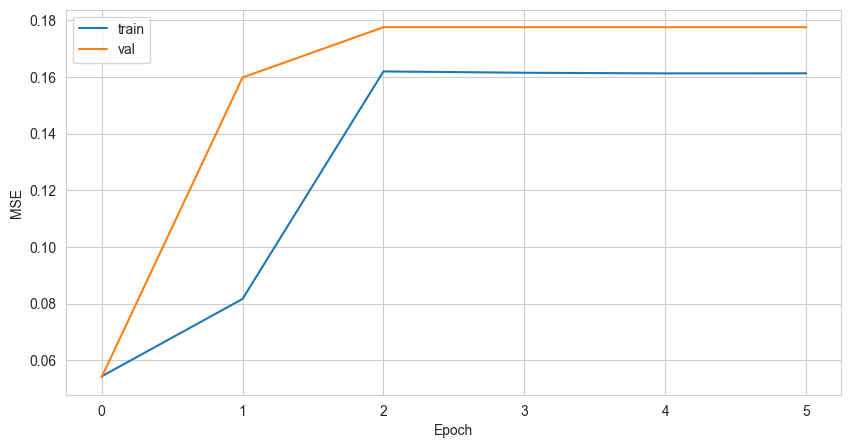

In [164]:
history = nn_model.fit(
    [X_u_tr, X_m_tr], y_tr,
    validation_data=([X_u_te, X_m_te], y_te),
    epochs=50, batch_size=256,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1
)

plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [165]:
preds_nn = np.clip(nn_model.predict([X_u_te, X_m_te], verbose=0).flatten() * 4.5 + 0.5, 0.5, 5.0)
true_r   = y_te * 4.5 + 0.5

rmse_nn = np.sqrt(mean_squared_error(true_r, preds_nn))
print(f"Neural CBF RMSE     : {rmse_nn:.4f}")
print(f"Traditional CBF RMSE: {rmse_cbf_only:.4f}")

Neural CBF RMSE     : 1.0456
Traditional CBF RMSE: 1.4030


### Task 9: Reinforcement Learning

In [166]:
reward_table = {
    (int(r["userId"]), int(r["movieId"])): 1 if r["rating"] >= 4 else -1
    for _, r in ratings.iterrows()
}

def get_reward(uid, mid):
    return reward_table.get((uid, mid), 0)

movie_ids = movies["movieId"].tolist()
print("action space:", len(movie_ids))

action space: 9742


In [167]:
class EpsilonGreedyBandit:
    def __init__(self, movie_ids, epsilon=0.1):
        self.epsilon = epsilon
        self.movie_ids = movie_ids
        self.Q = {m: 0.0 for m in movie_ids}
        self.N = {m: 0   for m in movie_ids}
        self.explores = 0
        self.exploits = 0

    def select(self):
        if np.random.rand() < self.epsilon:
            self.explores += 1
            return int(np.random.choice(self.movie_ids))
        self.exploits += 1
        return max(self.Q, key=self.Q.get)

    def update(self, mid, reward):
        self.N[mid] += 1
        self.Q[mid] += (reward - self.Q[mid]) / self.N[mid]

    def top_n(self, n=10):
        return sorted(self.Q, key=self.Q.get, reverse=True)[:n]


class UCBBandit:
    def __init__(self, movie_ids, c=2.0):
        self.c = c
        self.movie_ids = movie_ids
        self.Q = {m: 0.0 for m in movie_ids}
        self.N = {m: 0   for m in movie_ids}
        self.t = 0

    def select(self):
        self.t += 1
        ucb = {m: self.Q[m] + self.c * np.sqrt(np.log(self.t + 1) / (self.N[m] + 1e-5))
               for m in self.movie_ids}
        return max(ucb, key=ucb.get)

    def update(self, mid, reward):
        self.N[mid] += 1
        self.Q[mid] += (reward - self.Q[mid]) / self.N[mid]

    def top_n(self, n=10):
        return sorted(self.Q, key=self.Q.get, reverse=True)[:n]

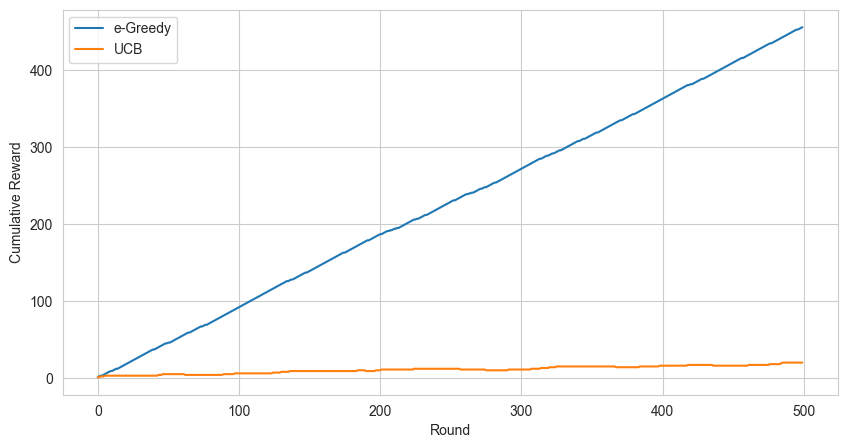

e-Greedy: explore=45  exploit=455


In [168]:
eg  = EpsilonGreedyBandit(movie_ids, epsilon=0.1)
ucb = UCBBandit(movie_ids, c=2.0)
eg_r, ucb_r = [], []

for _ in range(500):
    m1 = eg.select();  r1 = get_reward(1, m1);  eg.update(m1, r1);  eg_r.append(r1)
    m2 = ucb.select(); r2 = get_reward(1, m2); ucb.update(m2, r2); ucb_r.append(r2)

plt.plot(np.cumsum(eg_r),  label="e-Greedy")
plt.plot(np.cumsum(ucb_r), label="UCB")
plt.xlabel("Round")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.show()
print(f"e-Greedy: explore={eg.explores}  exploit={eg.exploits}")

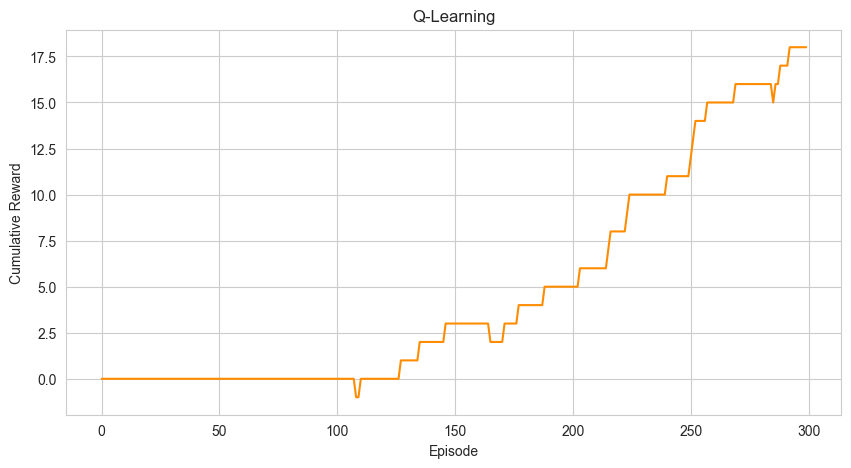

In [169]:
class QLearning:
    # Q(s,a) <- Q(s,a) + alpha * [r + gamma * max Q(s',a') - Q(s,a)]
    def __init__(self, movie_ids, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.movie_ids = movie_ids
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon
        self.Q = {}

    def _q(self, s, a):
        return self.Q.get((s, a), np.random.uniform(-0.01, 0.01))

    def act(self, s):
        if np.random.rand() < self.epsilon:
            return int(np.random.choice(self.movie_ids))
        return max(self.movie_ids, key=lambda a: self._q(s, a))

    def update(self, s, a, r, s2):
        best_next = max(self._q(s2, a2) for a2 in self.movie_ids)
        self.Q[(s, a)] = self._q(s, a) + self.alpha * (r + self.gamma * best_next - self._q(s, a))

    def recommend(self, s, n=10):
        return sorted(self.movie_ids, key=lambda a: self._q(s, a), reverse=True)[:n]


agent = QLearning(movie_ids[:500])
sim_users = ratings["userId"].unique()[:30]
q_r = []

for _ in range(300):
    uid  = int(np.random.choice(sim_users))
    a    = agent.act(uid)
    r    = get_reward(uid, a)
    uid2 = int(np.random.choice(sim_users))
    agent.update(uid, a, r, uid2)
    q_r.append(r)

plt.plot(np.cumsum(q_r), color="darkorange")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("Q-Learning")
plt.show()

In [170]:
rl_recs  = set(agent.recommend(1))
svd_recs = set(svd_recommend(1)["movieId"].tolist())
print("Q-Learning vs SVD overlap:", len(rl_recs & svd_recs), "/ 10")
# RL explores unseen movies while SVD just maximises predicted rating

Q-Learning vs SVD overlap: 0 / 10


## Part 6 - Explainability
### Task 10: SHAP (Feature-Based)

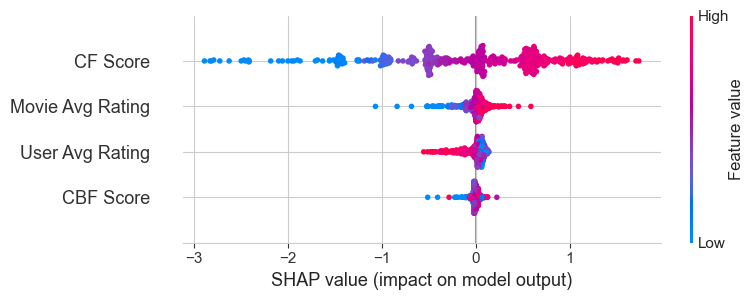

In [171]:
import shap

explainer = shap.TreeExplainer(meta_model)
sv = explainer.shap_values(X_test)

feat_names = ["CBF Score", "CF Score", "Movie Avg Rating", "User Avg Rating"]

shap.summary_plot(sv, X_test, feature_names=feat_names, show=True)

In [172]:
idx  = 0
pred = float(np.clip(meta_model.predict(X_test.iloc[[idx]])[0], 0.5, 5.0))

print(f"predicted={pred:.2f}  actual={y_test.iloc[idx]:.2f}")
for feat, val in zip(feat_names, sv[idx]):
    print(f"  {feat:<22} {val:+.4f}")

# e.g. "This movie was recommended because it matches your genre preferences (high CBF score)
# and has a strong overall rating."

predicted=3.39  actual=3.50
  CBF Score              -0.0566
  CF Score               +0.0523
  Movie Avg Rating       -0.1936
  User Avg Rating        +0.1403


### Task 11: Neighbourhood Explanations (CF)

In [173]:
def explain_ubcf(user_id, movie_id, k=5):
    # shows which similar users drove the recommendation
    # e.g. "Users who liked Inception also liked Interstellar"
    if movie_id not in user_item.columns:
        return "movie not in matrix"
    sims = user_similarity[user_id].drop(labels=[user_id], errors="ignore")
    sims = sims[user_item[movie_id].notna()].dropna().sort_values(ascending=False)
    if sims.empty:
        return "no similar users found"
    top_sims = sims.iloc[:k]
    top_rats = user_item.loc[top_sims.index, movie_id]
    title = movies[movies["movieId"] == movie_id]["title"].values
    title = title[0] if len(title) else str(movie_id)
    lines = [f"Why '{title}' was recommended for user {user_id}:", "-" * 50]
    for nb, sim in top_sims.items():
        lines.append(f"  user {nb}  sim={sim:.3f}  rated={top_rats[nb]}/5")
    lines.append(f"  predicted={ubcf_predict_rating(user_id, movie_id, k=k):.2f}")
    return "\n".join(lines)


demo_movie = ubcf_recommend(1, top_n=1)["movieId"].iloc[0]
print(explain_ubcf(1, demo_movie))

Why 'Awfully Big Adventure, An (1995)' was recommended for user 1:
--------------------------------------------------
  user 191  sim=0.179  rated=5.0/5
  predicted=5.00


### Task 12: LIME (Neural Network)

In [175]:
import lime
import lime.lime_tabular

X_comb_tr = np.hstack([X_u_tr, X_m_tr])
X_comb_te = np.hstack([X_u_te, X_m_te])
feat_names_comb = [f"u_{c}" for c in genre_cols] + [f"m_{c}" for c in mf_cols]

def predict_flat(X):
    n = X_u.shape[1]
    return nn_model.predict([X[:, :n].astype("float32"), X[:, n:].astype("float32")], verbose=0).flatten() * 4.5 + 0.5


lime_exp = lime.lime_tabular.LimeTabularExplainer(
    X_comb_tr, feature_names=feat_names_comb, mode="regression", random_state=SEED
)

exp = lime_exp.explain_instance(X_comb_te[0], predict_flat, num_features=10)
print(f"predicted: {predict_flat(X_comb_te[0].reshape(1, -1))[0]:.2f}")
for feat, w in exp.as_list():
    print(f"  {feat:<40}  {w:+.4f}")

predicted: 3.50
  m_Animation <= 0.00                       -0.2416
  0.00 < m_Drama <= 1.00                    +0.1994
  m_Crime <= 0.00                           -0.1789
  m_Children <= 0.00                        +0.1605
  m_War <= 0.00                             -0.1580
  m_Documentary <= 0.00                     -0.1270
  m_Adventure <= 0.00                       -0.1265
  m_Film-Noir <= 0.00                       -0.1213
  m_Mystery <= 0.00                         -0.1109
  m_Horror <= 0.00                          +0.1081


### Task 13: Comparing Explainability Methods

In [176]:
print("""
SHAP:
  Best for tree models. Gives exact Shapley values so you can see
  how much each feature pushed the rating up or down. If movie popularity
  dominates the SHAP plot it means the model is biased toward popular items.

Neighbourhood (k-NN):
  Most intuitive for users - "people like you rated this 4.5/5".
  Can reveal popularity bias if all top neighbours favour mainstream titles.

LIME:
  Useful for the neural network where SHAP is harder to apply.
  Approximates the model locally around one prediction. Feature names
  are less readable but it catches cases where the model leans too
  heavily on one genre flag.

All three confirm that CF Score and User Avg Rating are the strongest
predictors. For cold-start users the CBF score gains more weight.
""")


SHAP:
  Best for tree models. Gives exact Shapley values so you can see
  how much each feature pushed the rating up or down. If movie popularity
  dominates the SHAP plot it means the model is biased toward popular items.

Neighbourhood (k-NN):
  Most intuitive for users - "people like you rated this 4.5/5".
  Can reveal popularity bias if all top neighbours favour mainstream titles.

LIME:
  Useful for the neural network where SHAP is harder to apply.
  Approximates the model locally around one prediction. Feature names
  are less readable but it catches cases where the model leans too
  heavily on one genre flag.

All three confirm that CF Score and User Avg Rating are the strongest
predictors. For cold-start users the CBF score gains more weight.



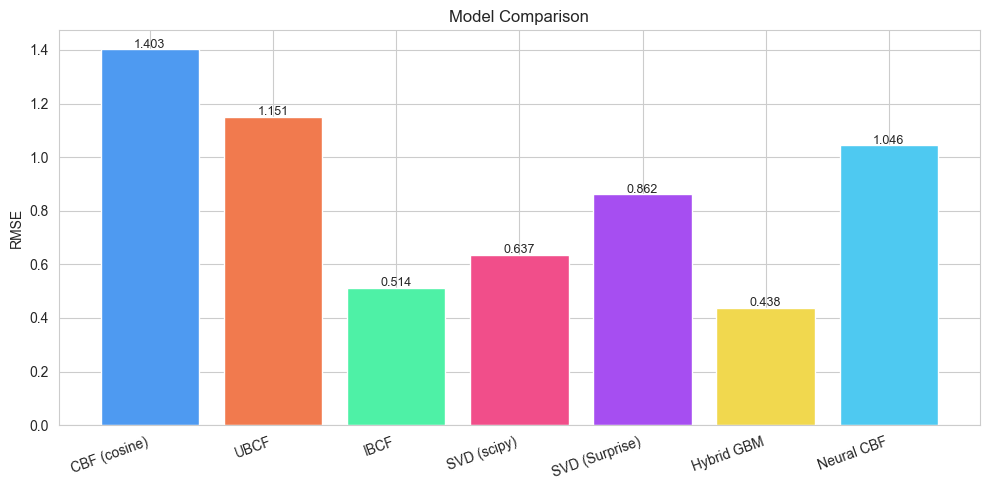

In [177]:
model_names = ["CBF (cosine)", "UBCF", "IBCF", "SVD (scipy)", "SVD (Surprise)", "Hybrid GBM", "Neural CBF"]

ibcf_rmse_val = np.sqrt(mean_squared_error(y_test.values, np.clip(X_test["cf"].values, 0.5, 5.0)))
rmse_scores   = [rmse_cbf_only, min(rmse_vals), ibcf_rmse_val, rmse_svd, rmse_surprise, rmse_hybrid, rmse_nn]

bars = plt.bar(model_names, rmse_scores,
               color=["#4e9af1","#f17a4e","#4ef1a6","#f14e8a","#a64ef1","#f1d84e","#4ec9f1"])
plt.ylabel("RMSE")
plt.title("Model Comparison")
plt.xticks(rotation=20, ha="right")
for b, v in zip(bars, rmse_scores):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()